# Tutorial 4: AquaHarmonics Expected Power Sensitivity under Irregular Waves

This tutorial computes the **sensitivity of expected electrical power** to BEM
hydrodynamic coefficients under **irregular (spectral) sea states** with
multiple phase realizations.

We use the same AquaHarmonics device as
[Tutorial 2](tutorial_2_AquaHarmonics_sensitivity.ipynb), but replace the
single regular wave with a Pierson-Moskowitz spectrum and multiple realizations.

### Key idea

For $N$ wave realizations, the expected optimal power is:

$$\mathbb{E}[\varphi^*] = \frac{1}{N} \sum_{k=1}^{N} \varphi^*_k(h)$$

The sensitivity of expected power to BEM parameters $h$ is simply the
**mean Fiacco gradient** across realizations:

$$\frac{d\,\mathbb{E}[\varphi^*]}{dh}
= \frac{1}{N} \sum_{k=1}^{N} \frac{d\varphi^*_k}{dh}$$

Both `sensitivity()` and `make_differentiable_solver()` handle this
multi-realization averaging automatically.

### Table of Contents

1. [Setup](#1.-Setup) -- device, PTO, forces, constraints
2. [Irregular Waves](#2.-Irregular-Waves) -- Pierson-Moskowitz spectrum
3. [Solve All Realizations](#3.-Solve-All-Realizations) -- IPOPT per realization
4. [Expected Power Sensitivity](#4.-Expected-Power-Sensitivity) -- `sensitivity()` and `make_differentiable_solver()`
5. [Visualize](#5.-Visualize) -- sensitivity bar charts, per-frequency plots
6. [Comparison with Regular Wave](#6.-Comparison-with-Regular-Wave) -- how irregular differs
7. [Summary](#7.-Summary)

## 1. Setup

Identical to Tutorial 2 -- the AquaHarmonics device with its multi-stage
drive train, generator loss map, and operational constraints.

In [19]:
import capytaine as cpy
from capytaine.io.meshio import load_from_meshio
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from wavespectra.construct.frequency import pierson_moskowitz

import wecopttool as wot
from wecopttool_differentiable import (
    WEC_IPOPT,
    sensitivity,
    make_differentiable_solver,
    BEMParams,
    extract_bem_params,
    extract_wave_data,
    plot_sensitivity_bars,
    plot_frequency_sensitivity,
)

plt.style.use('tableau-colorblind10')
cc = plt.rcParams['axes.prop_cycle'].by_key()['color']

### Geometry and BEM

In [20]:
# Hull mesh
ah_hull = wot.geom.AquaHarmonics()
mesh = ah_hull.mesh(mesh_size_factor=0.25)

# Capytaine FloatingBody
mesh_obj = load_from_meshio(mesh, 'AquaHarmonics')
lid_mesh = mesh_obj.generate_lid(-5e-2)
fb = cpy.FloatingBody(mesh=mesh_obj, lid_mesh=lid_mesh, name="AquaHarmonics")
fb.add_translation_dof(name="Heave")
ndof = fb.nb_dofs

# Hydrostatics and mass
g = 9.81
rho = 1025
fb.center_of_mass = [0, 0, 0]
fb.rotation_center = fb.center_of_mass
displaced_mass = fb.compute_rigid_body_inertia(rho=rho).values
displacement = displaced_mass / rho
fb.mass = np.atleast_2d(5e3)

# Frequency discretization
f1 = 0.05
nfreq = 20
freq = wot.frequency(f1, nfreq, False)

# BEM
bem_data = wot.run_bem(fb, freq, rho=rho, g=g)

print(f"Frequency range: {freq[0]:.3f} to {freq[-1]:.3f} Hz")
print(f"f1 = {f1} Hz, nfreq = {nfreq}")

/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/bodies/bodies.py:663: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'influenced_dof' ('influenced_dof',) The recommendation is to set join explicitly for this case.
  total_mass_xr = xr.merge([rigid_inertia_matrix_xr, other_dofs_inertia_matrix_xr], compat="override").inertia_matrix
/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/bodies/bodies.py:663: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'radiating_dof' ('radiating_d

[21:54:51] WARNING  center_of_mass already defined as [0, 0, 0].

           WARNING  rotation_center already defined as [0, 0, 0].

           WARNING  FloatingBody has no inertia_matrix field. The FloatingBody mass is defined and will be used for
                    calculating the inertia matrix.

/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/bodies/bodies.py:663: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'influenced_dof' ('influenced_dof',) The recommendation is to set join explicitly for this case.
  total_mass_xr = xr.merge([rigid_inertia_matrix_xr, other_dofs_inertia_matrix_xr], compat="override").inertia_matrix
/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/bodies/bodies.py:663: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'radiating_dof' ('radiating_d

           WARNING  FloatingBody has no hydrostatic_stiffness field. Capytaine will auto-populate the hydrostatic  
                    stiffness based on the provided mesh.

Output()

Frequency range: 0.050 to 1.000 Hz
f1 = 0.05 Hz, nfreq = 20


/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/io/xarray.py:428: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  dataset = xr.merge([dataset, diffraction_cases])
/Users/kapilkhanal/miniconda3/lib/python3.13/site-packages/capytaine/io/xarray.py:428: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  dataset = xr.merge([d

### PTO with generator loss map

In [21]:
# Drive train parameters
radii = {
    "S1": 0.02, "S2": 0.795, "S3": 0.1595, "S4": 0.200525, "S5": 0.40105,
    "S6": 0.12575, "S7": 0.103
}

inertias = {
    "Igen": 3.9, "I1": 0.029, "I2": 25.6, "I3": 1.43, "I4": 1.165, "I5": 4.99,
    "I6": 1.43, "I7": 1.5, "mps": 40
}

friction = {
    "Bgen": 7, "Bdrivetrain": 40, "Bshaft": 40, "Bspring_pulley": 80,
    "Bpneumatic_spring": 700, "Bpneumatic_spring_static1": 0,
    "Bpspneumatic_spring_static2": 0
}

airspring = {
    "gamma": 1.4, "height": 1, "diameter": 3, "area": 0.0709676,
    "press_init": 854e3, "vol_init": 1
}

gear_ratios = {
    "R21": radii['S2'] / radii['S1'],
    "R45": radii['S4'] / radii['S5'],
    "R67": radii['S6'] / radii['S7'],
    "spring": radii['S6'] * (radii['S4'] / radii['S5'])
}

inertia_pto = (
    (inertias["Igen"] + inertias["I1"]) * gear_ratios['R21']**2 +
    (inertias['I2'] + inertias['I3'] + inertias['I4']) +
    gear_ratios["R45"]**2 * (
        inertias['I5'] + inertias['I6'] +
        inertias["I7"] * gear_ratios['R67']**2 +
        inertias['mps'] * radii['S6']**2
    )
)

friction_pto = (
    friction['Bgen'] * gear_ratios['R21']**2 +
    friction['Bdrivetrain'] +
    gear_ratios["R45"]**2 * (
        friction["Bshaft"] +
        friction["Bspring_pulley"] * gear_ratios['R67']**2 +
        friction["Bpneumatic_spring"] * radii['S6']**2
    )
)

# Generator loss map
winding_resistance = 0.4
torque_coefficient = 1.5

def power_loss(speed, torque):
    return winding_resistance * (torque / torque_coefficient)**2

# Generator limits
rot_max = 10000 * 2 * np.pi / 60
torque_max = 300
power_max = 80e3

In [22]:
# PTO object
name = ["PTO_Heave"]
gear_ratio_generator = gear_ratios['R21'] / radii['S3']
kinematics = gear_ratio_generator * np.eye(ndof)
controller = wot.controllers.unstructured_controller()
nstate_opt = 2 * nfreq
pto_impedance = None
pto = wot.pto.PTO(
    ndof, kinematics, controller, pto_impedance, power_loss, name
)

### Additional forces and constraints

In [23]:
# Additional forces
def f_buoyancy(wec, x_wec, x_opt, wave, nsubsteps=1):
    return displacement * rho * g * jnp.ones([wec.ncomponents * nsubsteps, wec.ndof])

def f_gravity(wec, x_wec, x_opt, wave, nsubsteps=1):
    return -1 * wec.inertia_matrix.item() * g * jnp.ones([wec.ncomponents * nsubsteps, wec.ndof])

def f_pretension_wec(wec, x_wec, x_opt, wave, nsubsteps=1):
    f_b = f_buoyancy(wec, x_wec, x_opt, wave, nsubsteps)
    f_g = f_gravity(wec, x_wec, x_opt, wave, nsubsteps)
    return -1 * (f_b + f_g)

def f_pto_passive(wec, x_wec, x_opt, wave, nsubsteps=1):
    pos = wec.vec_to_dofmat(x_wec)
    vel = jnp.dot(wec.derivative_mat, pos)
    acc = jnp.dot(wec.derivative_mat, vel)
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)
    spring = -(gear_ratios['spring'] * airspring['gamma'] * airspring['area'] *
              airspring['press_init'] / airspring['vol_init']) * pos
    f_spring = jnp.dot(time_matrix, spring)
    fric = -(friction_pto +
             friction['Bpneumatic_spring_static1'] *
             gear_ratios['spring']) * vel
    f_fric = jnp.dot(time_matrix, fric)
    inertia = inertia_pto * acc
    f_inertia = jnp.dot(time_matrix, inertia)
    return f_spring + f_fric + f_inertia

def f_pto_line(wec, x_wec, x_opt, wave, nsubsteps=1):
    f_pto = pto.force_on_wec(wec, x_wec, x_opt, wave, nsubsteps)
    f_pre = f_pretension_wec(wec, x_wec, x_opt, wave, nsubsteps)
    return f_pto + f_pre

f_add = {
    'PTO': f_pto_line,
    'PTO_passive': f_pto_passive,
    'buoyancy': f_buoyancy,
    'gravity': f_gravity,
}

In [24]:
# Constraints
torque_peak_max = 280
rot_speed_max = 10000 * 2 * np.pi / 60
min_line_tension = -1000
nsubsteps = 2

def const_peak_torque_pto(wec, x_wec, x_opt, wave):
    torque = pto.force(wec, x_wec, x_opt, wave, nsubsteps)
    return torque_peak_max - jnp.abs(torque.flatten())

def const_speed_pto(wec, x_wec, x_opt, wave):
    rot_vel = pto.velocity(wec, x_wec, x_opt, wave, nsubsteps)
    return rot_speed_max - jnp.abs(rot_vel.flatten())

def const_power_pto(wec, x_wec, x_opt, wave):
    power_mech = (
        pto.velocity(wec, x_wec, x_opt, wave, nsubsteps) *
        pto.force(wec, x_wec, x_opt, wave, nsubsteps)
    )
    return power_max - jnp.abs(power_mech.flatten())

def constrain_min_tension(wec, x_wec, x_opt, wave):
    total_tension = -1 * f_pto_line(wec, x_wec, x_opt, wave, nsubsteps)
    return total_tension.flatten() + min_line_tension

def zero_mean_pos(wec, x_wec, x_opt, wave):
    return x_wec[0]

constraints = [
    {'type': 'ineq', 'fun': constrain_min_tension},
    {'type': 'ineq', 'fun': const_peak_torque_pto},
    {'type': 'ineq', 'fun': const_speed_pto},
    {'type': 'ineq', 'fun': const_power_pto},
    {'type': 'eq', 'fun': zero_mean_pos},
]

### Create `WEC_IPOPT` object

In [25]:
wec = WEC_IPOPT.from_bem(
    bem_data,
    constraints=constraints,
    f_add=f_add,
)

obj_fun = pto.average_power

print(f"nstate_wec = {wec.nstate_wec}")
print(f"nstate_opt = {nstate_opt}")
print(f"ndof       = {wec.ndof}")
print(f"nfreq      = {wec.nfreq}")

nstate_wec = 40
nstate_opt = 40
ndof       = 1
nfreq      = 20


## 2. Irregular Waves

We construct a Pierson-Moskowitz spectrum and generate multiple phase
realizations. Each realization has the same spectral content (amplitude per
frequency) but different random phases, representing different snapshots of
the same sea state.

In [26]:
# Sea state parameters
Hs = 1.5     # significant wave height [m]
Tp = 8.0     # peak period [s]
nrealizations = 3

fp = 1.0 / Tp
efth = pierson_moskowitz(freq=freq, hs=Hs, fp=fp)

# Generate irregular waves with fixed seed for reproducibility
waves = wot.waves.long_crested_wave(efth, nrealizations=nrealizations, direction=0, seed=42)

print(f"Sea state: Hs={Hs}m, Tp={Tp}s (Pierson-Moskowitz)")
print(f"Realizations: {nrealizations}")
print(f"Wave shape: {waves.shape}")
print(f"Dimensions: {waves.dims}  sizes: {dict(waves.sizes)}")

Sea state: Hs=1.5m, Tp=8.0s (Pierson-Moskowitz)
Realizations: 3
Wave shape: (20, 1, 3)
Dimensions: ('omega', 'wave_direction', 'realization')  sizes: {'omega': 20, 'wave_direction': 1, 'realization': 3}


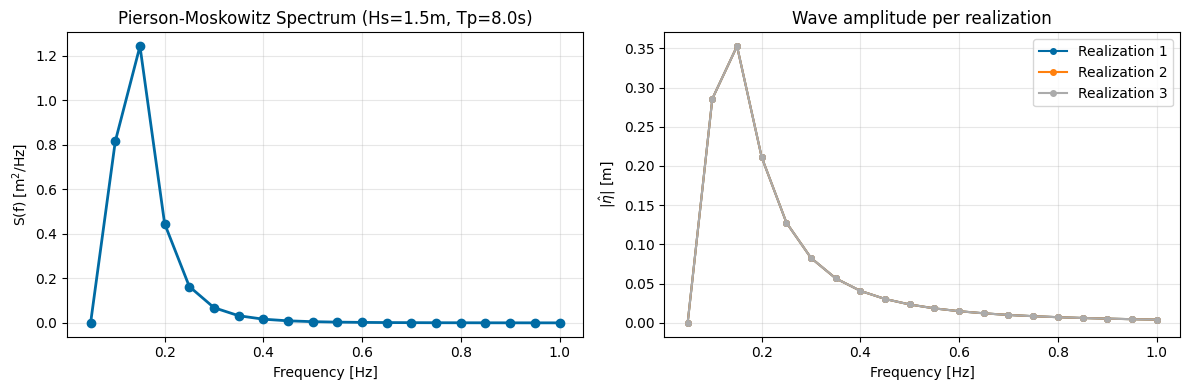

In [27]:
# Visualize the spectrum and wave amplitudes per realization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Spectrum
ax = axes[0]
ax.plot(efth.freq.values, efth.values.flatten(), 'o-', color=cc[0], linewidth=2)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('S(f) [m$^2$/Hz]')
ax.set_title(f'Pierson-Moskowitz Spectrum (Hs={Hs}m, Tp={Tp}s)')
ax.grid(alpha=0.3)

# Wave amplitude per frequency per realization
ax = axes[1]
for k, r in enumerate(waves.realization.values):
    wave_r = waves.sel(realization=r)
    amps = np.abs(wave_r.values.flatten())
    ax.plot(freq, amps, 'o-', label=f'Realization {k+1}', linewidth=1.5, markersize=4)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('|$\\hat{\\eta}$| [m]')
ax.set_title('Wave amplitude per realization')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Solve All Realizations

We solve the optimal control problem separately for each wave realization.
Each solve returns the optimal power and Lagrange multipliers for that
realization.

In [28]:
scale_x_wec = 1e1
scale_x_opt = 50e-2
scale_obj = 1e-3

solve_kw = dict(
    x_wec_0=np.ones(wec.nstate_wec) * 1e-3,
    x_opt_0=np.ones(nstate_opt) * 1e-3,
    scale_x_wec=scale_x_wec,
    scale_x_opt=scale_x_opt,
    scale_obj=scale_obj,
    optim_options={'max_iter': 2000, 'tol': 1e-8, 'print_level': 0},
)

results_list = []
for k, r in enumerate(waves.realization.values):
    wave_r = waves.sel(realization=[r])  # keep realization dim
    res = wec.solve(wave_r, obj_fun, nstate_opt, **solve_kw)[0]
    results_list.append(res)
    print(f"  Realization {k+1}: phi* = {res.fun/1e3:.2f} kW  "
          f"(status: {res.status}, success: {res.success})")

powers = [r.fun for r in results_list]
E_phi = np.mean(powers)

print(f"\nExpected power E[phi*] = {E_phi/1e3:.2f} kW")
print(f"  Std dev:  {np.std(powers)/1e3:.2f} kW")
print(f"  Range:    [{min(powers)/1e3:.2f}, {max(powers)/1e3:.2f}] kW")

[21:58:28] WARNING  b'Algorithm stopped at a point that was converged, not to "desired" tolerances, but to         
                    "acceptable" tolerances (see the acceptable-... options).'  (status 1)

  Realization 1: phi* = -1.54 kW  (status: 1, success: False)


[21:59:20] WARNING  b'Algorithm stopped at a point that was converged, not to "desired" tolerances, but to         
                    "acceptable" tolerances (see the acceptable-... options).'  (status 1)

  Realization 2: phi* = -1.49 kW  (status: 1, success: False)


[22:00:10] WARNING  b'Algorithm stopped at a point that was converged, not to "desired" tolerances, but to         
                    "acceptable" tolerances (see the acceptable-... options).'  (status 1)

  Realization 3: phi* = -1.56 kW  (status: 1, success: False)

Expected power E[phi*] = -1.53 kW
  Std dev:  0.03 kW
  Range:    [-1.56, -1.49] kW


## 4. Expected Power Sensitivity

We compute the mean Fiacco gradient $d\,\mathbb{E}[\varphi^*]/dh$ using
two methods:

1. **`sensitivity(wec, results_list, waves)`** (or `wec.compute_sensitivity(results_list, waves)`)
   -- pass the list of per-realization results; it computes the Fiacco VJP for each and returns the mean.
2. **`make_differentiable_solver()`** -- pass the multi-realization `waves`;
   the forward pass returns the mean objective, and `jax.grad` returns the
   mean gradient via the Fiacco backward pass.

### Method 1: `sensitivity()`

In [29]:
grad_sens = sensitivity(wec, results_list, waves)

# Or equivalently: grad_sens = wec.compute_sensitivity(results_list, waves)

print("Expected power sensitivity d(E[phi*])/dh  (via sensitivity):")
for field in BEMParams._fields:
    val = getattr(grad_sens, field)
    print(f"  {field:30s}  max|grad| = {float(jnp.max(jnp.abs(val))):.4e}")

Expected power sensitivity d(E[phi*])/dh  (via sensitivity):
  added_mass                      max|grad| = 1.1202e-02
  radiation_damping               max|grad| = 4.2512e-02
  hydrostatic_stiffness           max|grad| = 2.7039e-02
  friction                        max|grad| = 7.7086e-02
  Froude_Krylov_force             max|grad| = 4.8813e-02
  diffraction_force               max|grad| = 4.8813e-02
  inertia_matrix                  max|grad| = 2.0141e-02


### Method 2: `make_differentiable_solver()`

-- slower because always runs the forward solver again


In [30]:
f_diff = make_differentiable_solver(
    wec, waves, obj_fun, nstate_opt, **solve_kw
)

bp = extract_bem_params(wec._hydro_data)
grad_auto = jax.grad(f_diff)(bp)

print("Expected power sensitivity d(E[phi*])/dh  (via jax.grad):")
for field in BEMParams._fields:
    val = getattr(grad_auto, field)
    print(f"  {field:30s}  max|grad| = {float(jnp.max(jnp.abs(val))):.4e}")

[22:03:22] WARNING  b'Algorithm stopped at a point that was converged, not to "desired" tolerances, but to         
                    "acceptable" tolerances (see the acceptable-... options).'  (status 1)

[22:04:17] WARNING  b'Algorithm stopped at a point that was converged, not to "desired" tolerances, but to         
                    "acceptable" tolerances (see the acceptable-... options).'  (status 1)

[22:05:13] WARNING  b'Algorithm stopped at a point that was converged, not to "desired" tolerances, but to         
                    "acceptable" tolerances (see the acceptable-... options).'  (status 1)

Expected power sensitivity d(E[phi*])/dh  (via jax.grad):
  added_mass                      max|grad| = 1.1202e-02
  radiation_damping               max|grad| = 4.2512e-02
  hydrostatic_stiffness           max|grad| = 2.7039e-02
  friction                        max|grad| = 7.7086e-02
  Froude_Krylov_force             max|grad| = 4.8813e-02
  diffraction_force               max|grad| = 4.8813e-02
  inertia_matrix                  max|grad| = 2.0141e-02


### Cross-check: both methods agree

In [31]:
print(f"{'Parameter':30s} {'sensitivity':>15s} {'jax.grad':>15s} {'Match':>8s}")
print("-" * 72)
for field in BEMParams._fields:
    v1 = float(jnp.max(jnp.abs(getattr(grad_sens, field))))
    v2 = float(jnp.max(jnp.abs(getattr(grad_auto, field))))
    match = abs(v1 - v2) < max(abs(v1), abs(v2)) * 0.05 + 1e-10
    print(f"  {field:28s} {v1:15.4e} {v2:15.4e} {'OK' if match else 'MISMATCH':>8s}")

Parameter                          sensitivity        jax.grad    Match
------------------------------------------------------------------------
  added_mass                        1.1202e-02      1.1202e-02       OK
  radiation_damping                 4.2512e-02      4.2512e-02       OK
  hydrostatic_stiffness             2.7039e-02      2.7039e-02       OK
  friction                          7.7086e-02      7.7086e-02       OK
  Froude_Krylov_force               4.8813e-02      4.8813e-02       OK
  diffraction_force                 4.8813e-02      4.8813e-02       OK
  inertia_matrix                    2.0141e-02      2.0141e-02       OK


## 5. Visualize

### Per-parameter sensitivity magnitude

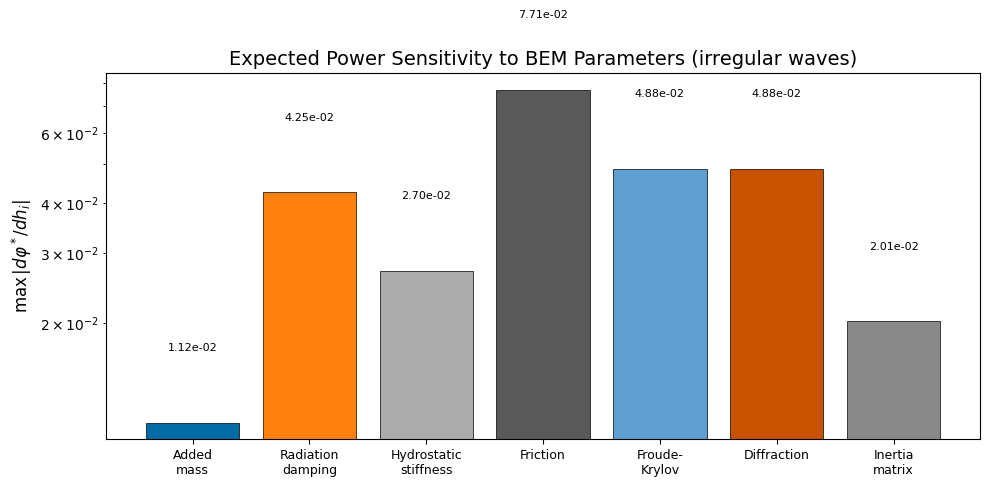

In [32]:
plot_sensitivity_bars(
    grad_sens,
    title='Expected Power Sensitivity to BEM Parameters (irregular waves)',
    metric='max_abs', colors=cc,
)
plt.show()

### Per-frequency sensitivity

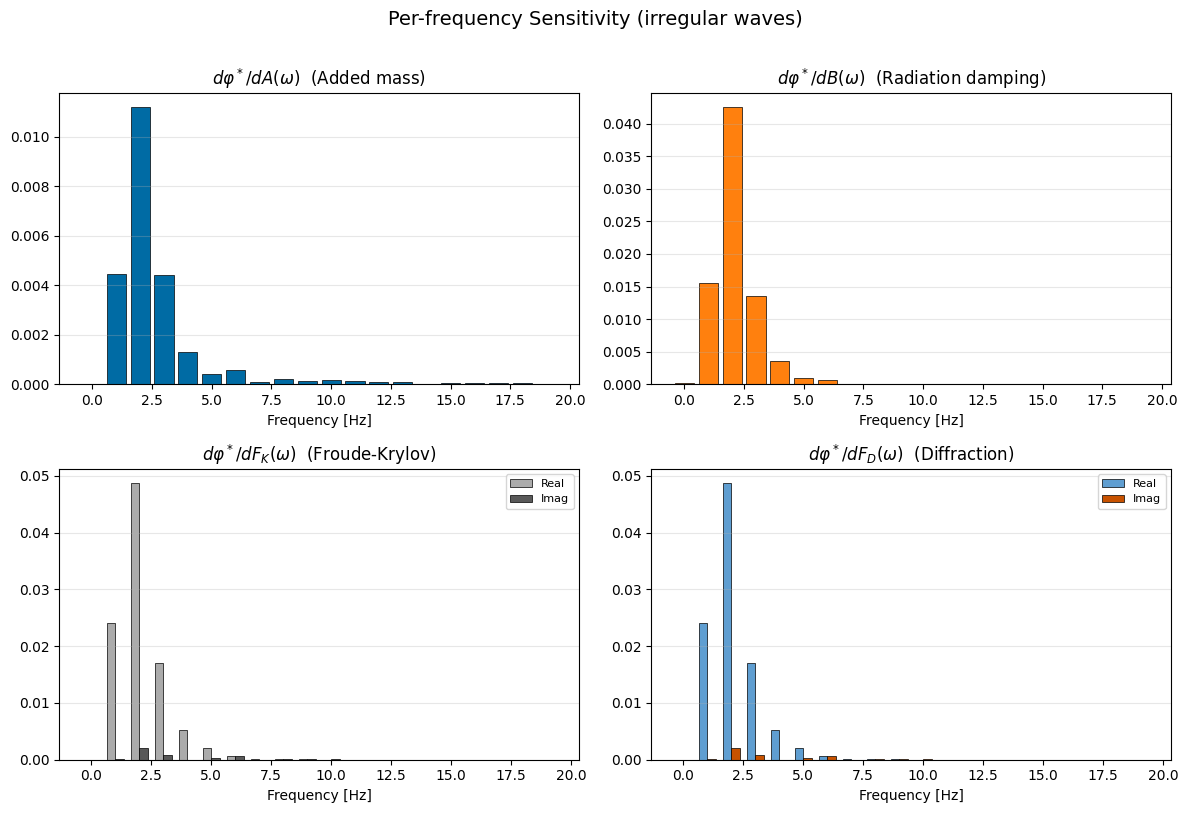

In [33]:
omega = 2 * np.pi * freq
plot_frequency_sensitivity(
    grad_sens, omega,
    title='Per-frequency Sensitivity (irregular waves)',
    colors=cc,
)
plt.show()

### Per-realization breakdown

Compute the Fiacco gradient for each realization individually to see
how sensitivity varies across wave phases.

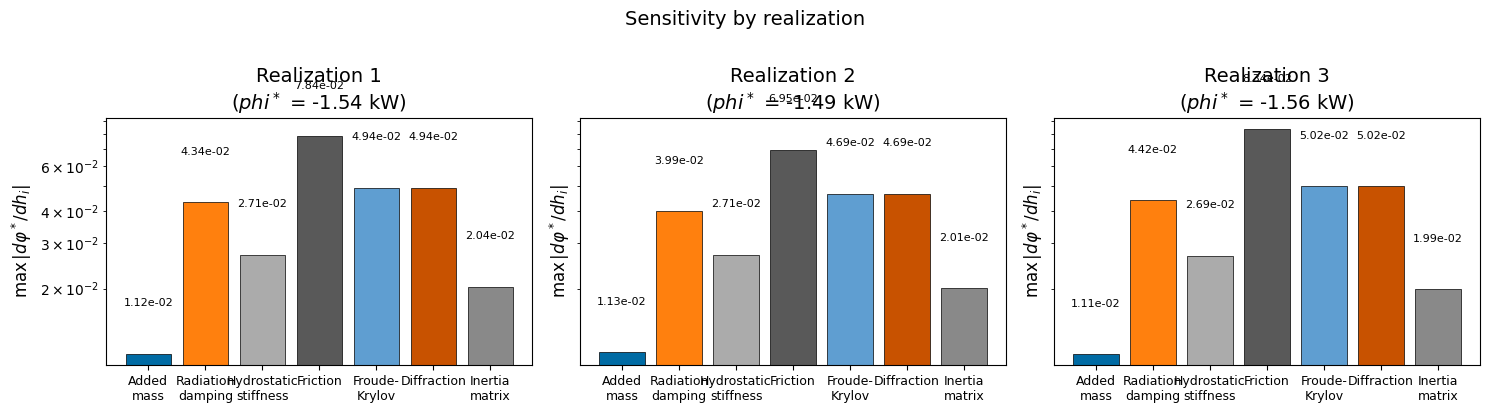

In [34]:
fig, axes = plt.subplots(1, nrealizations, figsize=(5 * nrealizations, 4),
                         sharey=True)

grad_per_real = []
for k, r in enumerate(waves.realization.values):
    wave_r = waves.sel(realization=[r])  # keep realization dim
    grad_k = sensitivity(wec, results_list[k], wave_r)
    grad_per_real.append(grad_k)
    plot_sensitivity_bars(
        grad_k,
        title=f'Realization {k+1}\n($phi^*$ = {results_list[k].fun/1e3:.2f} kW)',
        metric='max_abs', colors=cc, ax=axes[k],
    )

fig.suptitle('Sensitivity by realization', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Comparison with Regular Wave

For context, we also compute the sensitivity under a single regular wave
at the peak frequency, to see how the irregular-wave sensitivity differs.

In [35]:
# Regular wave at peak frequency
amplitude_reg = 0.5
wavefreq_reg = fp
waves_reg = wot.waves.regular_wave(f1, nfreq, wavefreq_reg, amplitude_reg, phase=30, direction=0)

res_reg = wec.solve(waves_reg, obj_fun, nstate_opt, **solve_kw)[0]
grad_reg = sensitivity(wec, res_reg, waves_reg)

print(f"Regular wave:   phi* = {res_reg.fun/1e3:.2f} kW  (f={wavefreq_reg:.3f} Hz, A={amplitude_reg}m)")
print(f"Irregular wave: E[phi*] = {E_phi/1e3:.2f} kW  (Hs={Hs}m, Tp={Tp}s, N={nrealizations})")

[22:05:15] WARNING  Requested frequency 0.125 Hz is not in array. Using nearest value of 0.1 Hz.

[22:09:46] WARNING  b'Algorithm stopped at a point that was converged, not to "desired" tolerances, but to         
                    "acceptable" tolerances (see the acceptable-... options).'  (status 1)

Regular wave:   phi* = -1.44 kW  (f=0.125 Hz, A=0.5m)
Irregular wave: E[phi*] = -1.53 kW  (Hs=1.5m, Tp=8.0s, N=3)


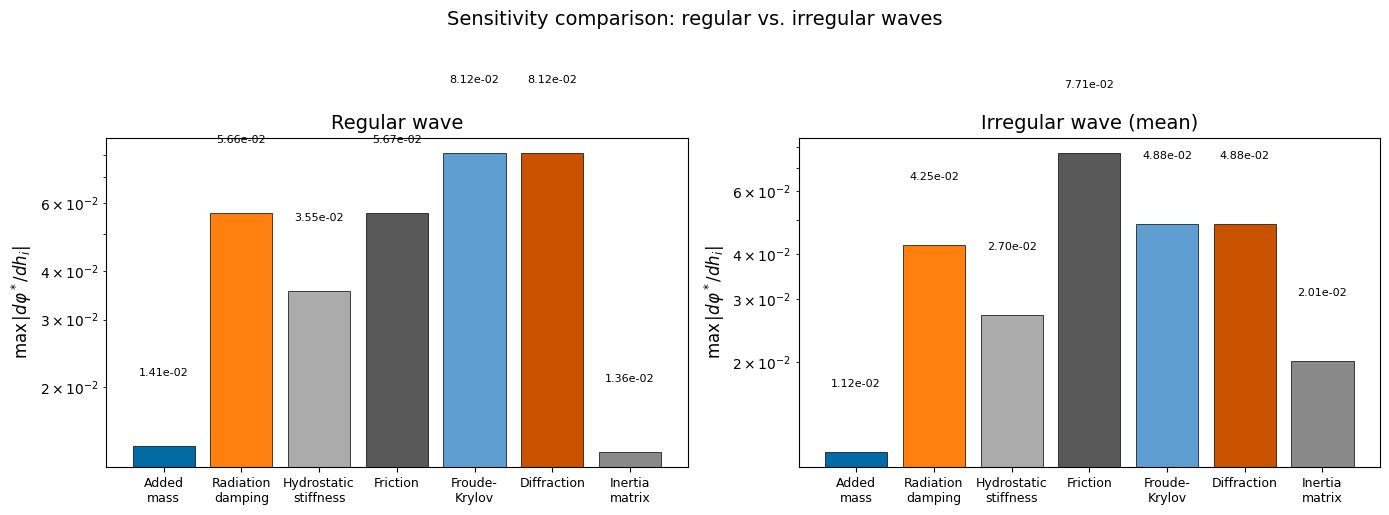

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_sensitivity_bars(grad_reg, title='Regular wave', metric='max_abs',
                      colors=cc, ax=axes[0])
plot_sensitivity_bars(grad_sens, title='Irregular wave (mean)', metric='max_abs',
                      colors=cc, ax=axes[1])

fig.suptitle('Sensitivity comparison: regular vs. irregular waves', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Summary

This tutorial demonstrated **expected power sensitivity under irregular waves**
for the AquaHarmonics WEC.

### Key results

- Both `sensitivity()` and `make_differentiable_solver()` handle
  multi-realization averaging automatically -- the user simply passes a list
  of results (or multi-realization waves) and gets back the mean gradient.
- The Fiacco sensitivity is computed **per realization** and averaged,
  giving the gradient of expected power $d\,\mathbb{E}[\varphi^*]/dh$.
- Sensitivity profiles can vary significantly across realizations due to
  different wave phases activating different constraints.
- Irregular-wave sensitivity typically differs from regular-wave sensitivity,
  reflecting the broader frequency content and phase randomness.

### Cost

| Component | Cost |
|---|---|
| IPOPT solve | $N$ solves (1 per realization) |
| Fiacco VJP | $N$ VJPs (~ms each) |
| **Total** | dominated by IPOPT solves |

For $N = 3$ realizations, the total cost is ~$3\times$ a single regular-wave solve.

### Next steps

- Use the expected-power sensitivity in shape optimization (Tutorial 3) under
  irregular waves for more realistic design optimization.
- Increase `nrealizations` for better statistical estimates (at linear cost).
- Compare sensitivity across different sea states (varying $H_s$, $T_p$).